In [16]:
# import libraries and load dataset

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [17]:
# basic dataset overview

df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

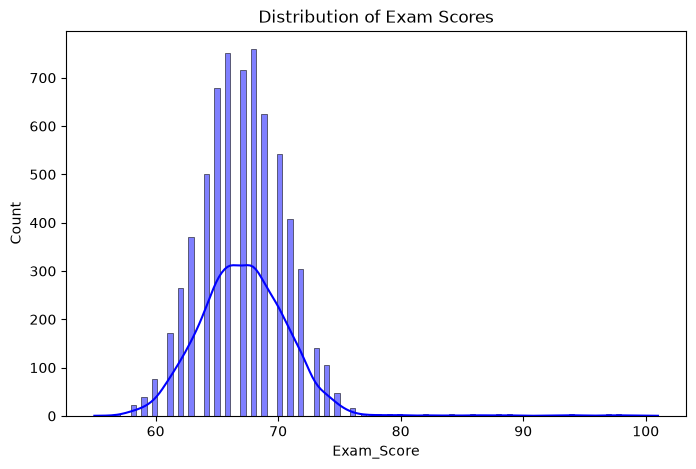

In [18]:
# distribution of exam scores

plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], kde=True, color='blue')
plt.title("Distribution of Exam Scores")
plt.show()

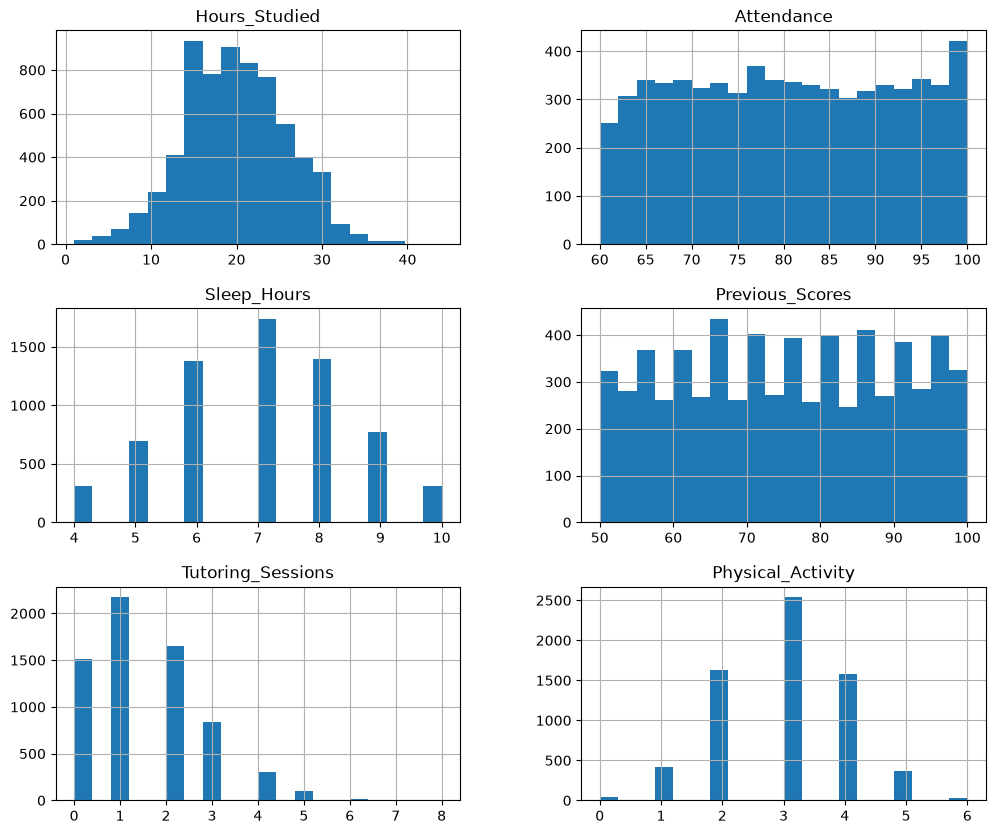

In [19]:
# univariant analysis of numerical features

num_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores',
            'Tutoring_Sessions','Physical_Activity','Distance_from_Home']

df[num_cols].hist(figsize=(12,10), bins=20)
plt.show()

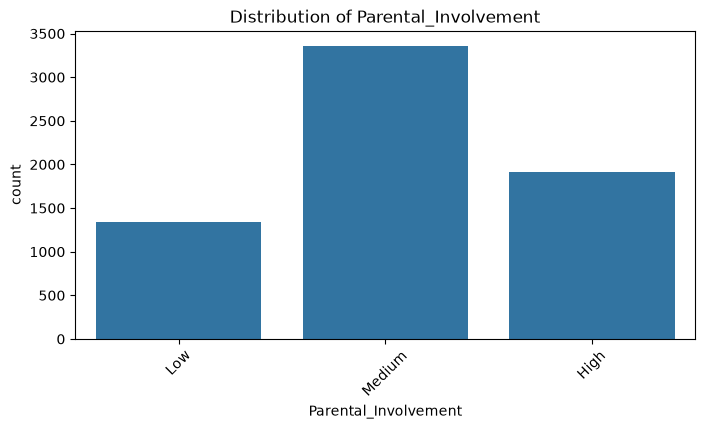

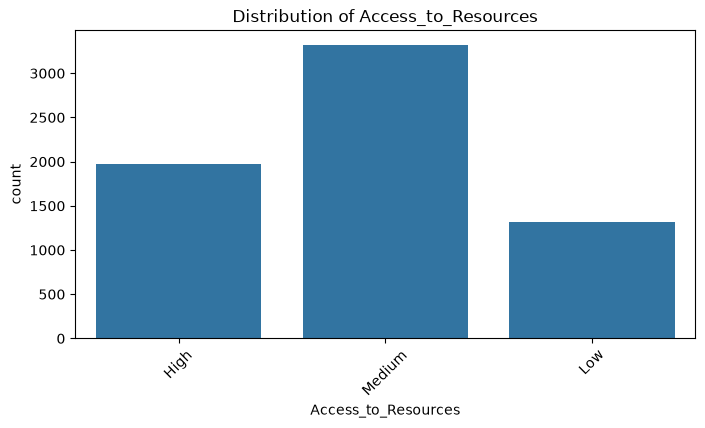

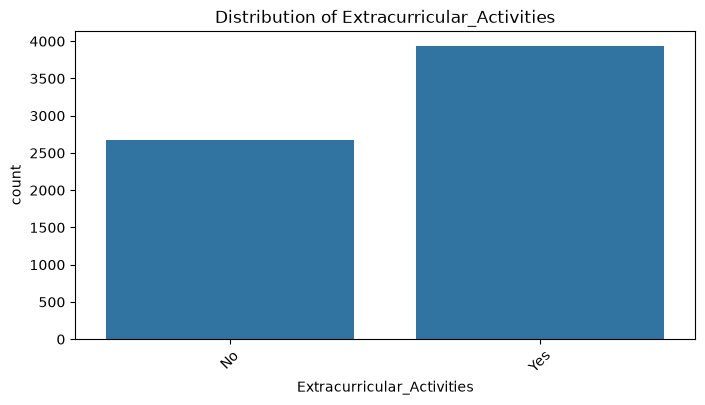

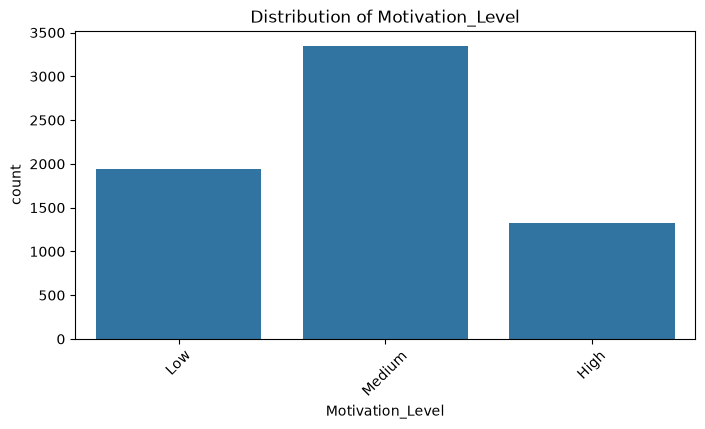

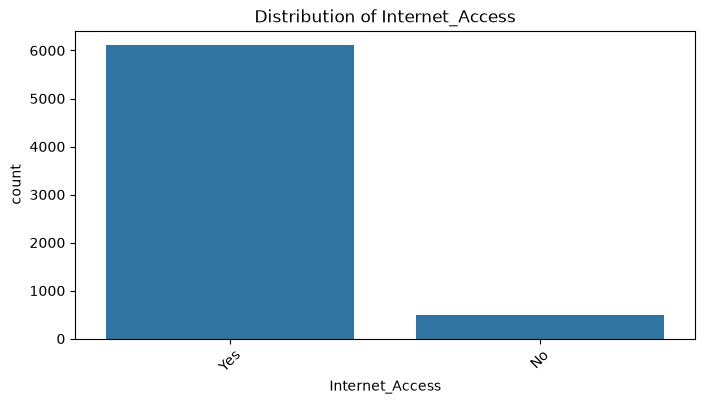

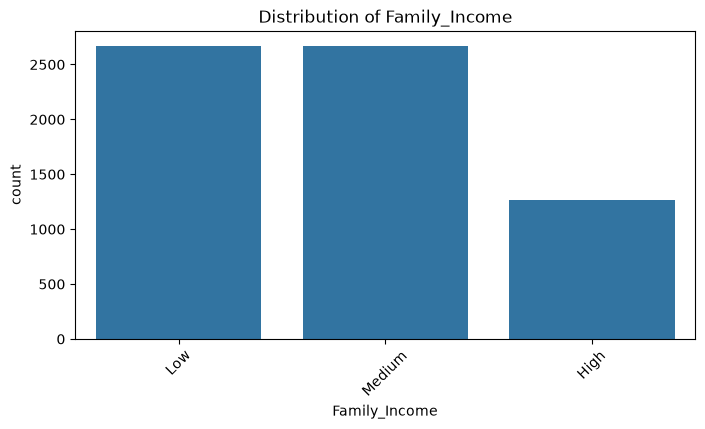

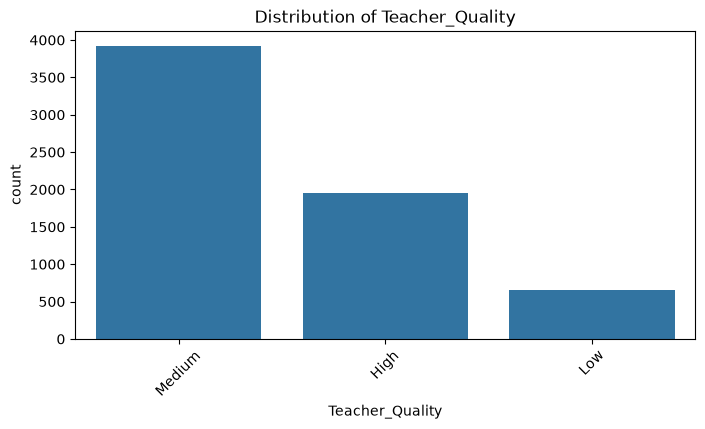

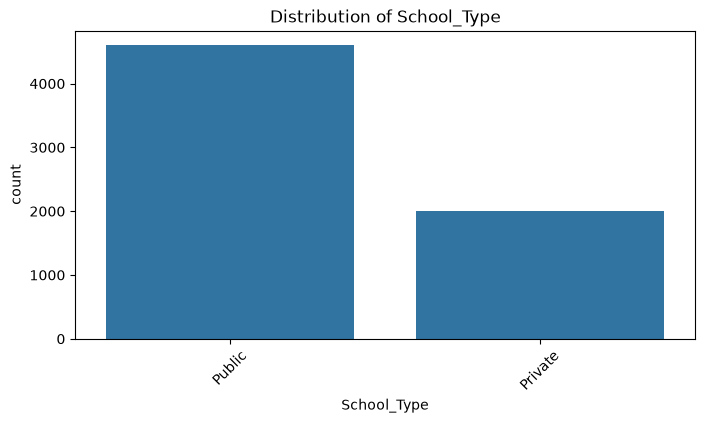

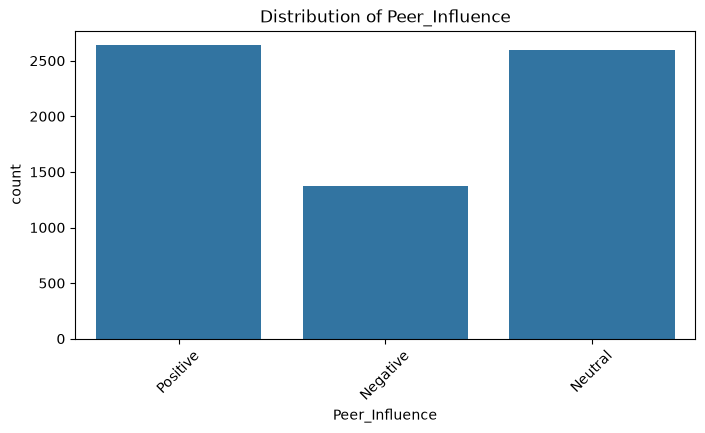

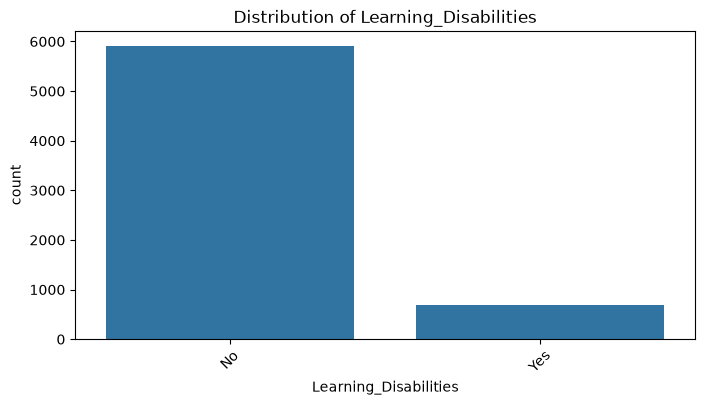

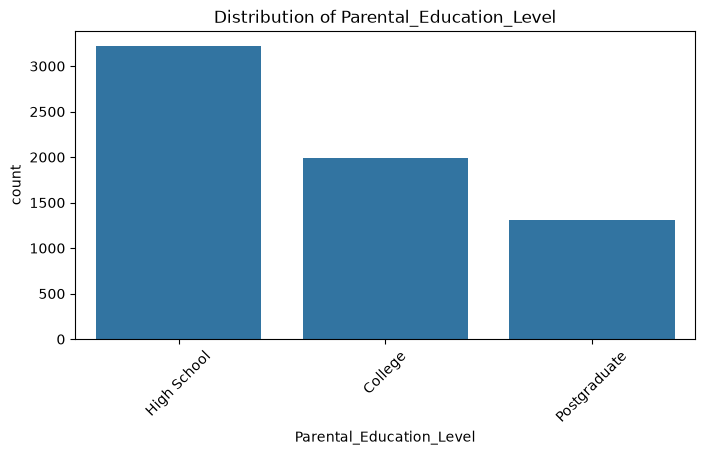

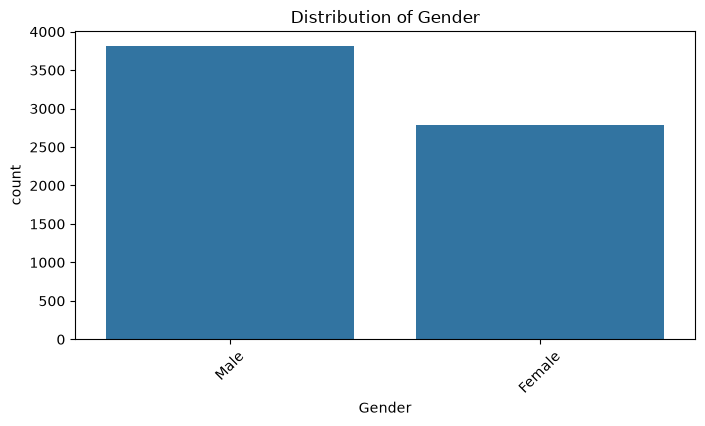

In [20]:
# univariant analysis of categorical features

cat_cols = ['Parental_Involvement','Access_to_Resources','Extracurricular_Activities',
            'Motivation_Level','Internet_Access','Family_Income','Teacher_Quality',
            'School_Type','Peer_Influence','Learning_Disabilities','Parental_Education_Level',
            'Gender']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

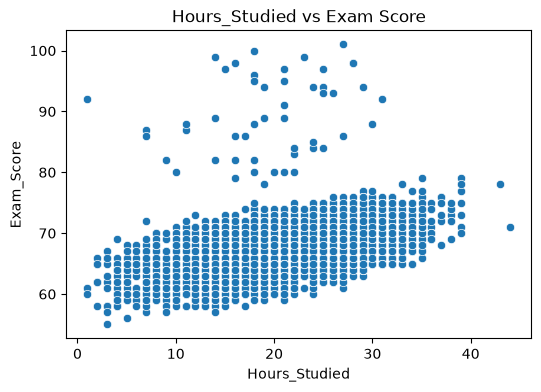

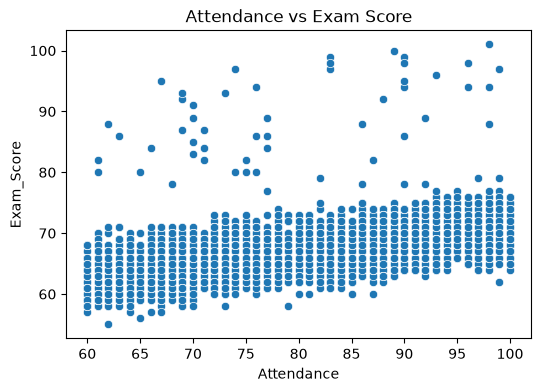

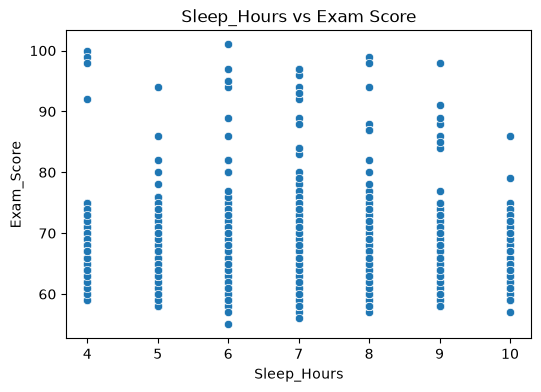

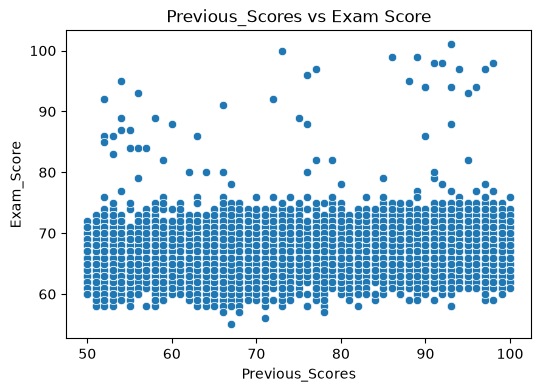

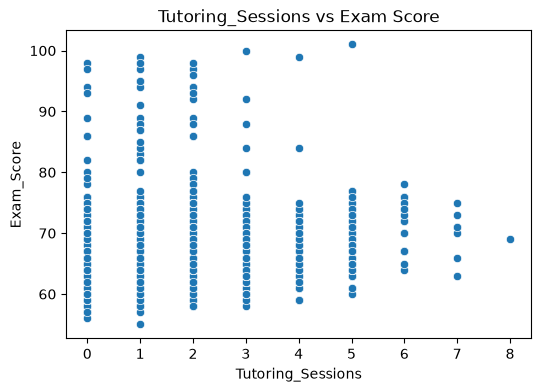

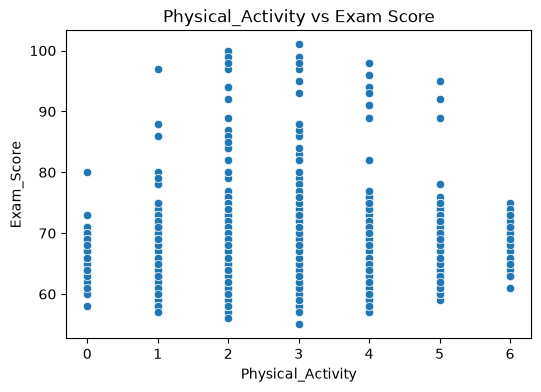

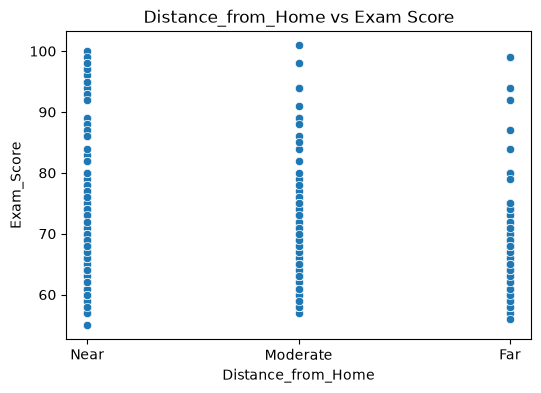

In [21]:
# exam score vs numerical features

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['Exam_Score'])
    plt.title(f"{col} vs Exam Score")
    plt.show()

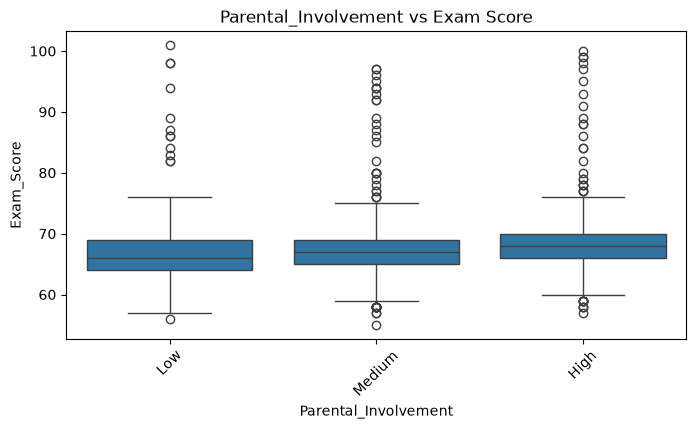

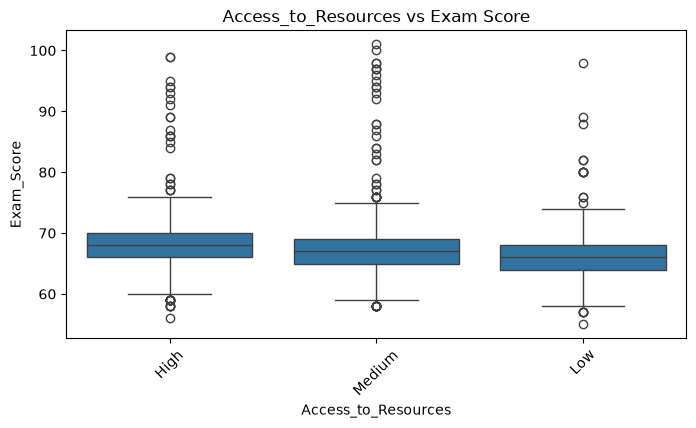

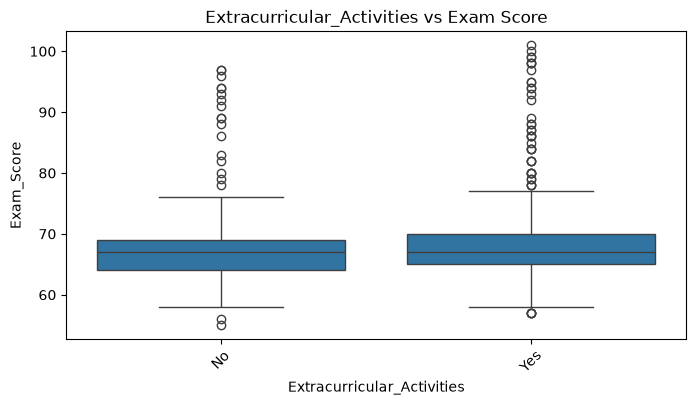

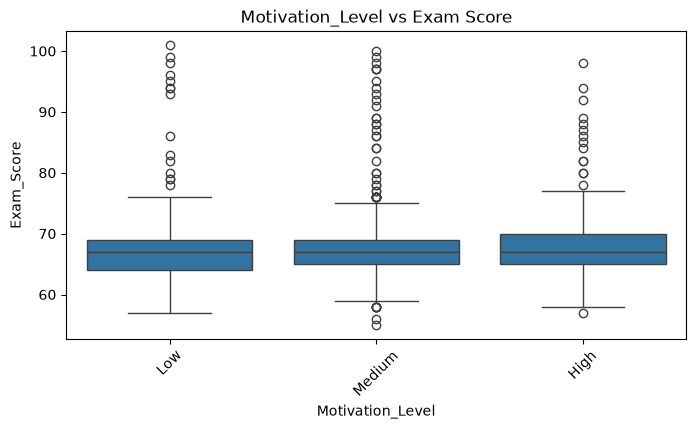

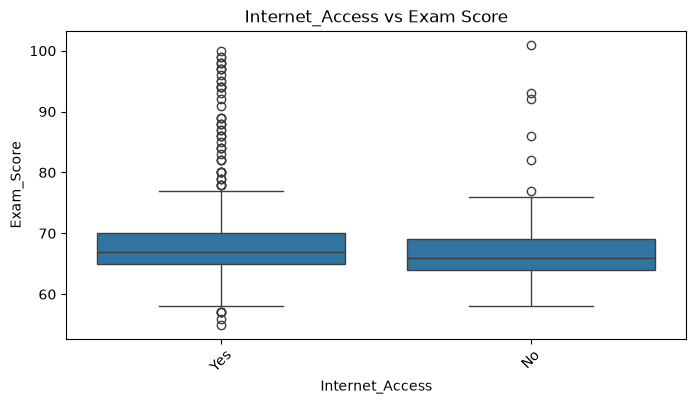

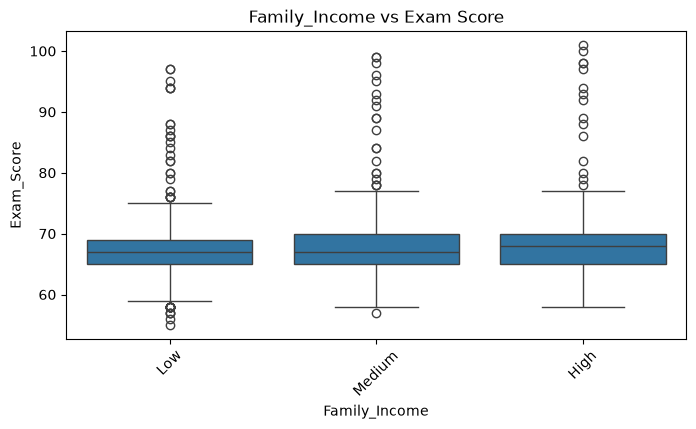

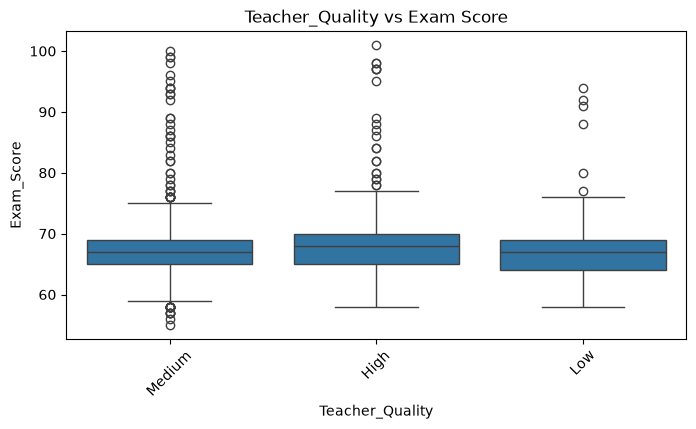

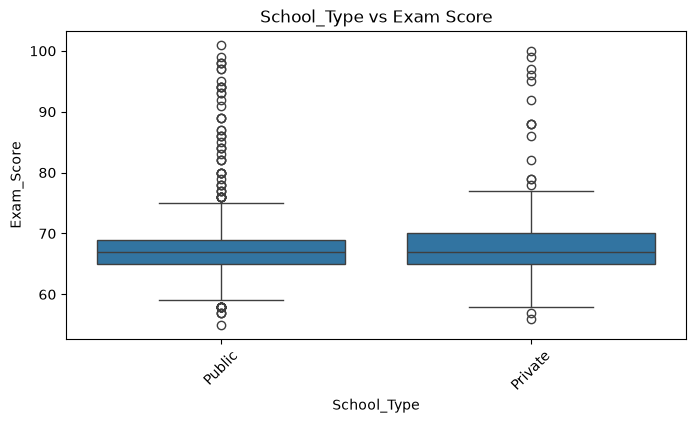

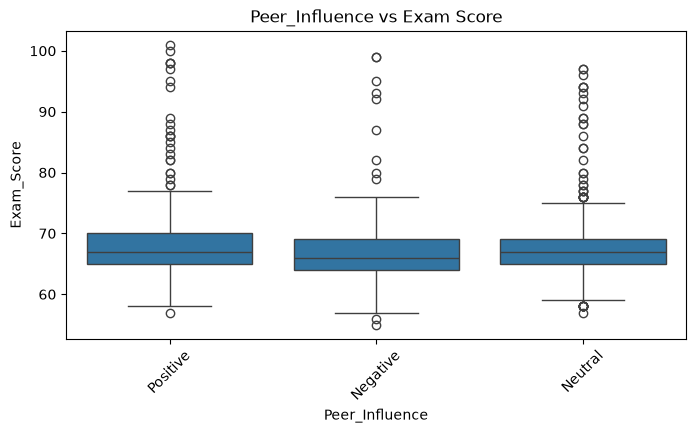

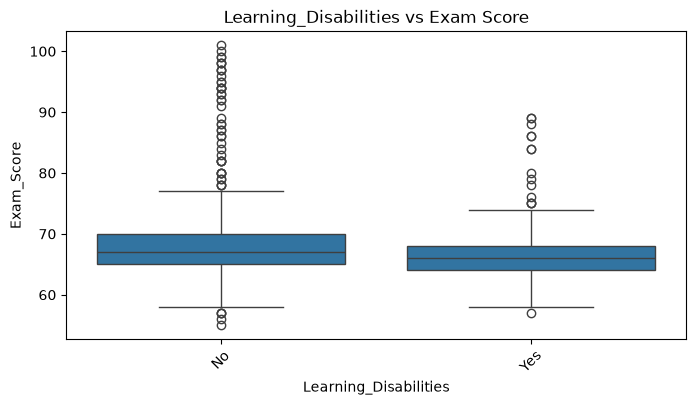

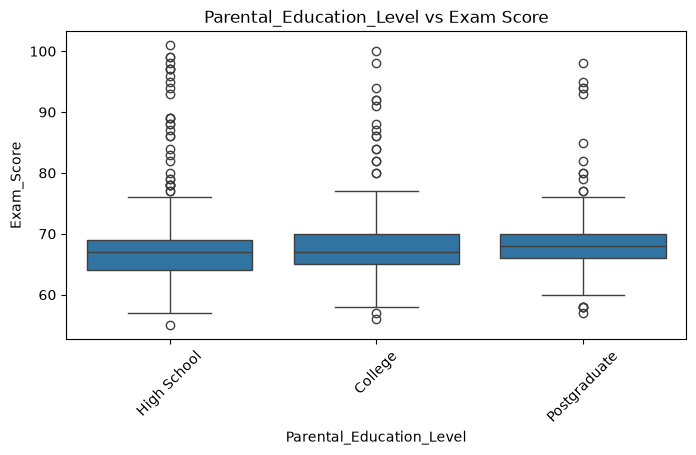

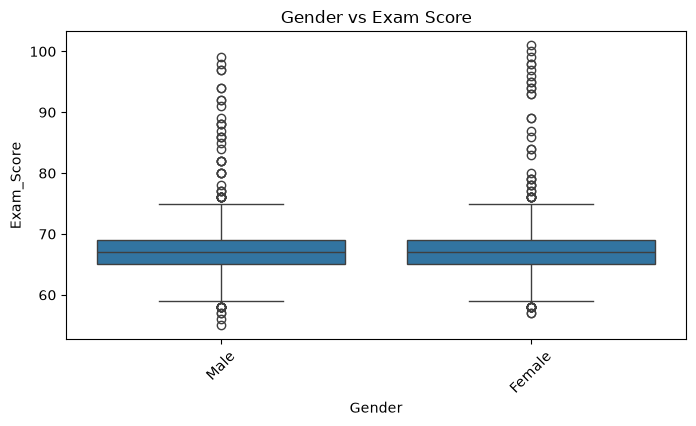

In [22]:
# exam score vs categorical features

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y='Exam_Score', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Exam Score")
    plt.show()

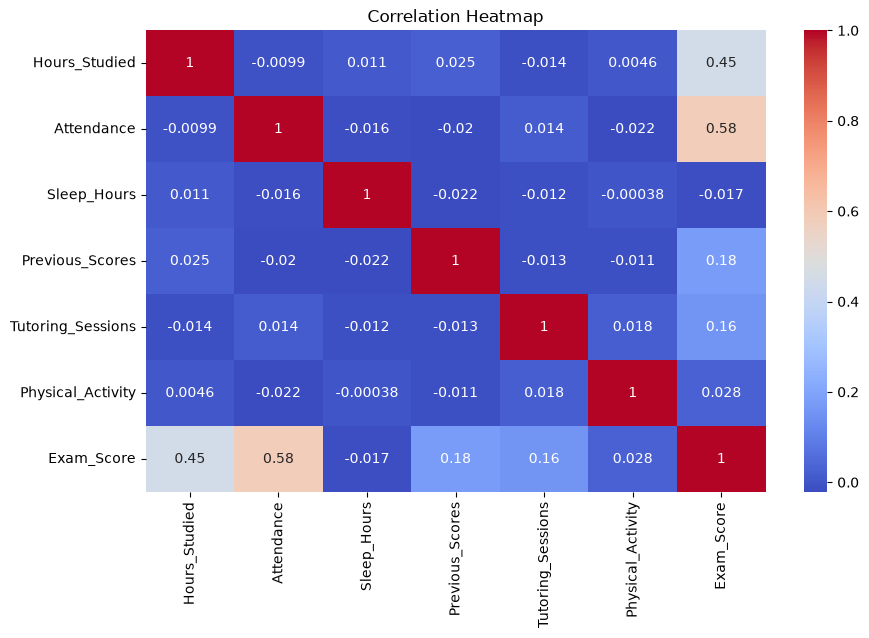

In [23]:
# correlation analysis

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

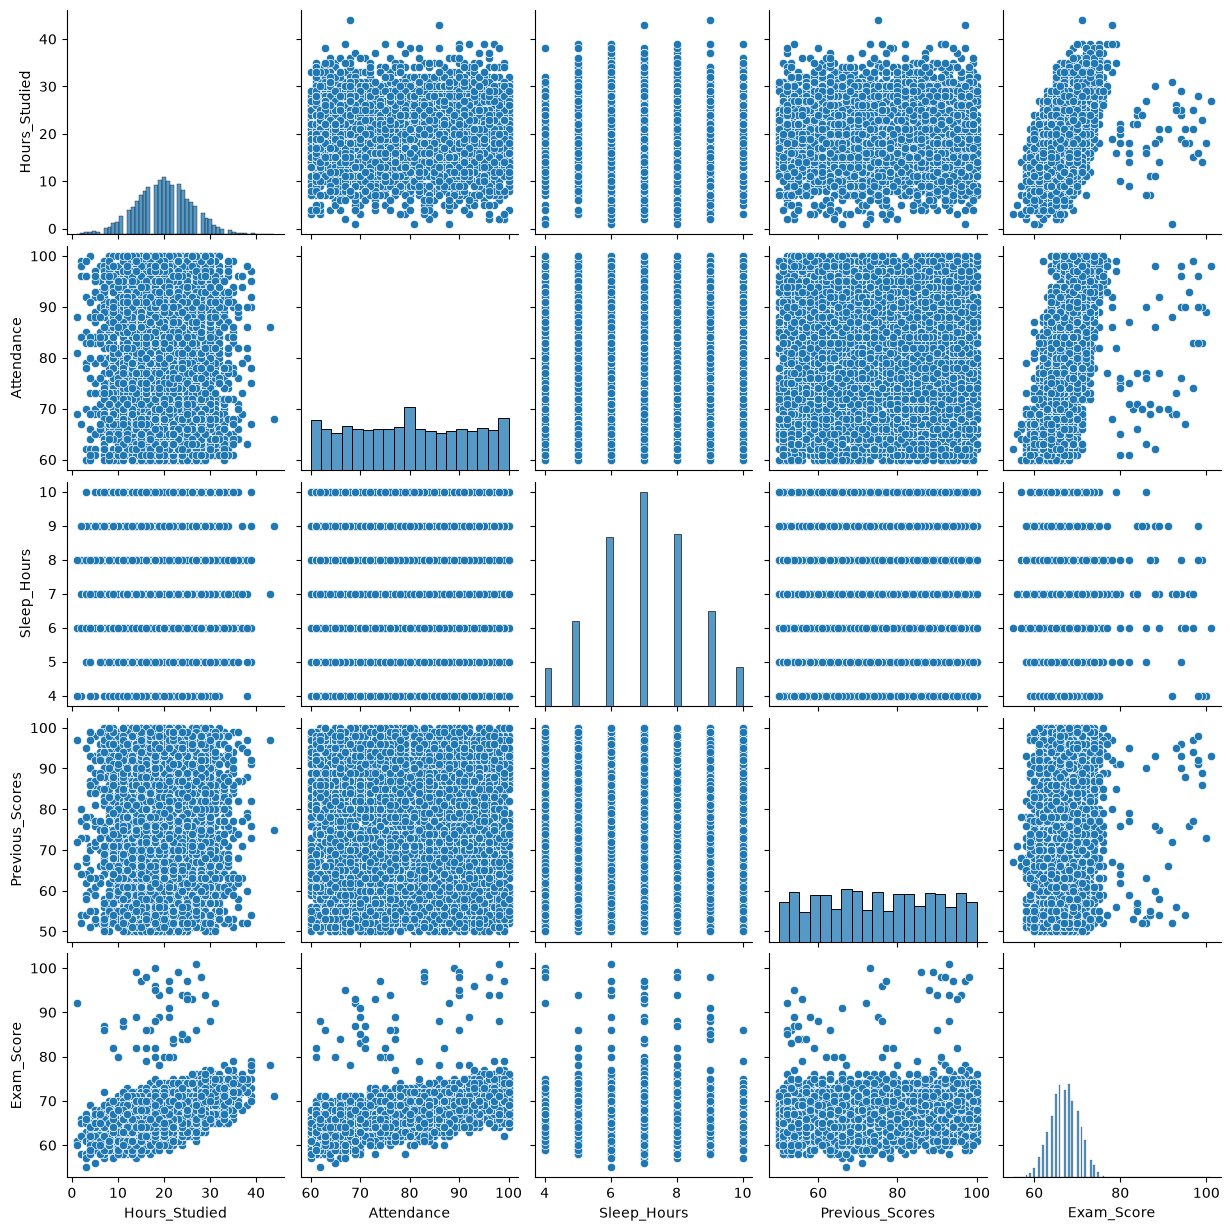

In [24]:
# pairplot of selected features

sns.pairplot(df[['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Exam_Score']])
plt.show()

# Key Insight Summary

Students with high motivation score significantly better.

Hours_Studied and Previous_Scores have strong positive correlation with Exam_Score.

Sleep_Hours shows a moderate effect — too little sleep reduces performance.

Teacher_Quality and Parental_Involvement show clear score differences.

Students with internet access perform better on average.

Family_Income affects access to resources → impacts scores.